Start with LR and SW
1. Analytical sensitivity limit (ASL) substitution
2. Testing for outliers (see the map)-isolated forests
3. Gridding-weighted median of sample size

In [ ]:
import sys
sys.path.append('..')
import pandas as pd
import numpy as np
import myfunction as mf
from path_config import *


from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from pyod.models.iforest import IForest
import matplotlib.pyplot as plt

def get_outlier(df_x, col_1, col_2, col_3, int_fraction):
    df = df_x.copy()
    scaler = MinMaxScaler(feature_range=(0, 1))

    df[[col_1, col_2, col_3]] = scaler.fit_transform(df[[col_1, col_2, col_3]])



    df[[col_1, col_2, col_3]].head()
    X1 = df[col_1].values.reshape(-1, 1)

    X2 = df[col_2].values.reshape(-1, 1)
    X3 = df[col_3].values.reshape(-1, 1)
    X = np.concatenate((X1, X2, X3), axis=1)

    random_state = np.random.RandomState(1024)

    outliers_fraction = int_fraction


    classifiers = {
        'Isolation Forest': IForest(contamination=outliers_fraction, random_state=random_state),



    }
    xx, yy, zz = np.meshgrid(np.linspace(0, 1, 200), np.linspace(0, 1, 200), np.linspace(0, 1, 200))


    for i, (clf_name, clf) in enumerate(classifiers.items()):


        clf.fit(X)


        scores_pred = clf.decision_function(X) * -1


        y_pred = clf.predict(X)

        n_inliers = len(y_pred) - np.count_nonzero(y_pred)

        n_outliers = np.count_nonzero(y_pred == 1)
        plt.figure(figsize=(10, 10))


        dfx = df
        dfx['outlier'] = y_pred.tolist()
        IX1 = np.array(dfx[col_1][dfx['outlier'] == 0]).reshape(-1, 1)
        IX2 = np.array(dfx[col_2][dfx['outlier'] == 0]).reshape(-1, 1)
        IX3 = np.array(dfx[col_3][dfx['outlier'] == 0]).reshape(-1, 1)

        OX1 = dfx[col_1][dfx['outlier'] == 1].values.reshape(-1, 1)
        OX2 = dfx[col_2][dfx['outlier'] == 1].values.reshape(-1, 1)
        OX3 = dfx[col_3][dfx['outlier'] == 1].values.reshape(-1, 1)
        print('OUTLIERS : ', n_outliers, 'INLIERS : ', n_inliers, clf_name)
        fig = plt.figure()

        ax = fig.add_subplot(111, projection='3d')
        ax.scatter(IX1, IX2, IX3, c='white', s=6, edgecolor='k')
        ax.scatter(OX1, OX2, OX3, c='red', s=6, edgecolor='k')

        plt.xlim((0, 1))
        plt.ylim((0, 1))
        plt.title(clf_name)
        plt.show()
        return dfx



In [ ]:

df_lr_raw = pd.read_csv(path_part + 'lr_raw.csv')
df_sw_raw = pd.read_csv(path_part + 'sw_raw.csv')



df_lr_raw = df_lr_raw[(df_lr_raw['type'] == 0) | ((df_lr_raw['type'] == 1) & (df_lr_raw['limit_value'] <= 1))]
df_sw_raw = df_sw_raw[(df_sw_raw['type'] == 0) | ((df_sw_raw['type'] == 1) & (df_sw_raw['limit_value'] <= 1))]

df_lr_raw = df_lr_raw[(df_lr_raw['poid'].notna())&(df_lr_raw['spid'].notna())]
df_sw_raw = df_sw_raw[df_sw_raw['poid'].notna()]

df_lr_raw = df_lr_raw[['paid','spid','poid', 'year', 'organ', 'habit', 'lon', 'lat', 'value', 'n']]
df_sw_raw = df_sw_raw[['paid','poid', 'year', 'lon', 'lat', 'sw_value', 'n']]

df_sw_raw = df_sw_raw[df_sw_raw['year'].notna()]

df_lr_raw.to_csv(path_part + 'lr_use.csv', index=False)
df_sw_raw.to_csv(path_part + 'sw_use.csv', index=False)

### 预处理lr

添加sp，po，country相关数据  
方便瞅瞅数据的大概的情况以及绘图  
数据不更改只运行一次即可  

In [ ]:

from netCDF4 import Dataset
from scipy.spatial import cKDTree


df_data_raw = pd.read_csv(path_part + "lr_use.csv")

nc_file_path = "C:/Users/dell/OneDrive/file/nc/country_id_1x1.nc"
nc_data = Dataset(nc_file_path, 'r')

lon = nc_data.variables['lon'][:]
lat = nc_data.variables['lat'][:]
country_id = nc_data.variables['country_id'][:]

lon_lat_grid = np.array(np.meshgrid(lon, lat))
grid_shape = lon_lat_grid.shape[1:]
lon_lat_grid = lon_lat_grid.reshape(2, -1).T

tree = cKDTree(lon_lat_grid)

points_to_query = df_data_raw[['lon', 'lat']].values

distances, indices = tree.query(points_to_query)

df_data_raw['country_id'] = country_id.reshape(-1)[indices]


dict_inf = {"sp":['phylum',"class","length_last","weight_last","troph_last", 'rank','family','genus','species'],
             "po":["po_chain","posname",'posid','po_carbon','po_f_carbon','po_classification'],
             'country':['country_code', 'country','continent','income'],
             'habit':['habitat']}

df_data_raw2 = mf.append_inf(df_data_raw, dict_inf)

df_data_raw_select = df_data_raw2[(df_data_raw2['posid'].notna())&(df_data_raw2['rank']=='SPECIES')]
print(df_data_raw2.shape)
print(df_data_raw_select.shape)

df_data_raw_select = mf.df_merge_lat_lon(df_data_raw_select)

print(df_data_raw_select.shape)
print(df_data_raw_select.isnull().sum()[df_data_raw_select.isnull().sum() > 0])
df_data_raw_select.to_csv(path_part0_pre + "lr_use_pre_select.csv", index=False)

(68232, 31)
(64520, 31)
(64520, 32)
length_last       466
weight_last     21665
troph_last        216
country_code     1281
country          1281
continent        1281
income           1281
dtype: int64


In [ ]:

df_data_raw_select = pd.read_csv(path_part0_pre + "lr_use_pre_select.csv")
list_items = ['posid','spid','class','family','genus','country_code','year','lat_lon']
for item in list_items:

    df_item = mf.col_value(df_data_raw_select,item)
    print(item + ' num:',df_item.shape[0])

posid num: 88
spid num: 457
class num: 16
family num: 171
genus num: 335
country_code num: 37
year num: 52
lat_lon num: 1916


C:\Users\dell\AppData\Local\Temp\ipykernel_49084\2873538778.py:1: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  df_data_raw_select = pd.read_csv(path_pre + "lr_use_pre_select.csv")


In [ ]:

df_data_raw_select = pd.read_csv(path_part0_pre + "lr_use_pre_select.csv")
df_data_raw_select["cl_or"] = df_data_raw_select["class"] + '_' + df_data_raw_select["organ"]
pd.set_option('display.max_rows', None)
print(df_data_raw_select.shape)
list_items = ['posname','class','year','cl_or','po_classification','po_chain','organ']
for item in list_items:

    df_item = mf.col_value(df_data_raw_select,item)
    print(df_item)




(64520, 33)
           posname  count       per
0             PFOS  10012  0.155177
1             PFDA   4079  0.063221
2           PFUnDA   4038  0.062585
3             PFNA   4008  0.062120
4           PFDoDA   3840  0.059516
5             PFOA   3733  0.057858
6            PFHxS   3457  0.053580
7           PFTrDA   2782  0.043118
8            PFHpA   2507  0.038856
9           PFTeDA   2449  0.037957
10            FOSA   2394  0.037105
11           PFHxA   2365  0.036655
12            PFBS   2218  0.034377
13           PFPeA   1986  0.030781
14            PFBA   1772  0.027464
15            PFDS   1657  0.025682
16           PFHpS   1022  0.015840
17           PFPeS    777  0.012043
18        8:2 FTSA    752  0.011655
19        6:2 FTSA    749  0.011609
20         MeFOSAA    748  0.011593
21         EtFOSAA    745  0.011547
22            PFNS    723  0.011206
23        4:2 FTSA    721  0.011175
24          MeFOSA    482  0.007471
25         HFPO-DA    438  0.006789
26          EtFO

C:\Users\dell\AppData\Local\Temp\ipykernel_49084\975937568.py:1: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  df_data_raw_select = pd.read_csv(path_pre + "lr_use_pre_select.csv")


In [ ]:


df_data_pre = pd.read_csv(path_part0_pre + "lr_use_pre_select.csv", low_memory=False)
print('lr_use_pre shape:', df_data_pre.shape)
list_class = mf.col_value(df_data_pre,'class')['class'].unique().tolist()[0:1]
list_organ = ['muscle','liver','whole']

mask = (df_data_pre['class'].isin(list_class)) & (df_data_pre['organ'].isin(list_organ))
df_data_pre_select = df_data_pre[mask].copy()


df_data_pre_select.loc[:, 'year'] = df_data_pre_select['year'].astype(float)
df_data_pre_select.loc[:, 'year'] = df_data_pre_select['year'].astype(int)


mask_year = (df_data_pre_select['year'] <= 2020) & (df_data_pre_select['year'] >= 2000)
df_data_pre_select = df_data_pre_select[mask_year]
print(df_data_pre_select.shape)

df_sw_all = pd.read_csv(path_part + "sw_use.csv")
print('sw_use shape:', df_sw_all.shape)
df_sw_select = df_sw_all[(df_sw_all['year'].notna())&(df_sw_all['poid'].notna())]
dict_inf = {"po":['posname']}
df_sw_select = mf.append_inf(df_sw_select,dict_inf)


df_po = pd.read_excel(path_file + "inf.xlsx",sheet_name="po_pfas")
list_po_inf = df_po['poid'][(df_po['log_Koil_w'].notna())&(df_po['density'].notna())].tolist()

df_sp = pd.read_excel(path_file + "inf.xlsx",sheet_name="sp_pfas")
list_sp_inf = df_sp['spid'][(df_sp['length_last'].notna())&(df_sp['weight_last'].notna())&(df_sp['troph_last'].notna())].tolist()


list_po_lr = df_data_pre_select['poid'].unique().tolist()
list_po_sw = df_sw_select['poid'].unique().tolist()


list_po = list(set(list_po_lr) & set(list_po_sw) & set(list_po_inf))
print('po list:', len(list_po))

df_data_pre_select = df_data_pre_select[df_data_pre_select['poid'].isin(list_po)]
df_data_pre_select = df_data_pre_select[df_data_pre_select['spid'].isin(list_sp_inf)]
df_sw_select = df_sw_select[df_sw_select['poid'].isin(list_po)]
print('lr_select shape:', df_data_pre_select.shape)
print('sw_select shape:', df_sw_select.shape)

df_data_pre_select.to_csv(path_part0_temp + "lr_select.csv",index=False)
df_sw_select.to_csv(path_part0_temp + 'sw_select.csv', index=False)

lr_use_pre shape: (64520, 32)
(36138, 32)
sw_use shape: (95081, 7)
po list: 39
lr_select shape: (35695, 32)
sw_select shape: (93737, 8)


### lr后续

包括异常值，加权平均值，网格化，转换和标准化

(35707, 32)
OUTLIERS :  312 INLIERS :  35394 Isolation Forest


<Figure size 1000x1000 with 0 Axes>

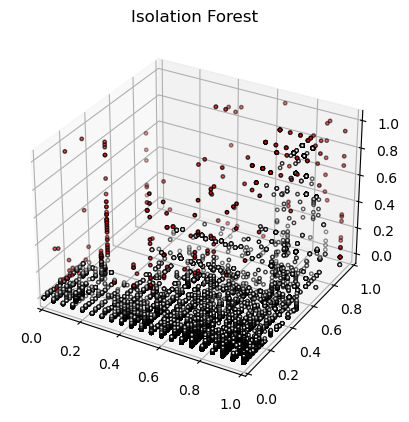

(35394, 9)


In [ ]:

df_data_pre_select = pd.read_csv(path_part0_temp + "lr_select.csv")
print(df_data_pre_select.shape)
df_icicle_w_o_outlier = df_data_pre_select.copy()



df_icicle_w_o_outlier['year_count'] = df_icicle_w_o_outlier.groupby('posname')['year'].transform('nunique')
df_icicle_w_o_outlier['value_median'] = df_icicle_w_o_outlier.groupby('posname')['value'].transform('median')

sorted_posnames = df_icicle_w_o_outlier.groupby('posname').agg({
    'year_count': 'first',
    'value_median': 'first'
}).sort_values(['year_count', 'value_median'], ascending=[False, False]).index

posname_rank = {name: rank for rank, name in enumerate(sorted_posnames)}
df_icicle_w_o_outlier['posname_rank'] = df_icicle_w_o_outlier['posname'].map(posname_rank)


le_ind = LabelEncoder()
po_le = le_ind.fit_transform(df_icicle_w_o_outlier["posname_rank"])

df_icicle_w_o_outlier["po_copy"] = po_le
df_icicle_w_o_outlier["po_copy"] = po_le
df_icicle_w_o_outlier['value_copy'] = (df_icicle_w_o_outlier['value'] - df_icicle_w_o_outlier.groupby('po_copy')['value'].transform('min')) / (df_icicle_w_o_outlier.groupby('po_copy')['value'].transform('max') - df_icicle_w_o_outlier.groupby('po_copy')['value'].transform('min'))
df_icicle_w_o_outlier["year_copy"] = df_icicle_w_o_outlier["year"]

df_icicle_w_o_outlier = df_icicle_w_o_outlier.dropna(subset=["year_copy","po_copy","value_copy"])
df_icicle_w_o_outlier = get_outlier(df_icicle_w_o_outlier,"year_copy", "po_copy","value_copy", 0.01)


df_icicle_w_o_outlier = df_icicle_w_o_outlier[df_icicle_w_o_outlier["outlier"]==0]

list_3 = ["habitat","spid","posname","lon","lat","organ","year", "value", 'n']
list_4 = ["habitat","spid","lon","lat","organ","year",'n']
df_icicle_w_o_outlier = df_icicle_w_o_outlier[list_3]
print(df_icicle_w_o_outlier.shape)
df_icicle_w_o_outlier.to_csv(path_part0_temp + "lr_outlier.csv",index=False)




In [ ]:




df_outlier = pd.read_csv(path_part0_temp + "lr_outlier.csv")
print(df_outlier.shape)
list_1 = ["habitat","spid","posname","lon","lat","organ","year"]
list_2 = ["habitat","spid","posname","lon","lat","organ","year", "n","value"]
list_3 = ["habitat","spid","posname","lon","lat","organ","year", "value"]
df_icicle = df_outlier[list_2]
df_icicle_w = mf.get_weight_count(df_icicle,list_1,'mean') 

df_icicle_w_o = df_icicle_w[list_3]
print(df_icicle_w_o.shape)
df_icicle_w_o.to_csv(path_part0_temp + "lr_weight_avg.csv",index=False)



(35394, 9)
['n', 'value']
habitat~spid~posname~lon~lat~organ~year
['habitat~spid~posname~lon~lat~organ~year', 'n', 'value']
26381
(26381, 8)


In [ ]:

df_weight = pd.read_csv(path_part0_temp + "lr_weight_avg.csv")
print(df_weight.shape)
int_grid = 1
def lat_lon_to_grid(lat, lon, grid_size=1):
    return round(lat / grid_size) * grid_size, round(lon / grid_size) * grid_size


df_weight['lat_grid'], df_weight['lon_grid'] = zip(*df_weight.apply(lambda row: lat_lon_to_grid(row['lat'], row['lon'], int_grid), axis=1))


df_grid = df_weight.groupby(['lat_grid', 'lon_grid', 'habitat', 'spid', 'organ', 'year', 'posname'])['value'].mean().reset_index()
print(df_grid.shape)
df_grid = df_grid[df_grid['habitat'].isin(['Inland_water', 'Ocean'])]
df_grid.to_csv(path_part0_pre + "lr_grid.csv",index=False)

(26381, 8)
(21599, 8)


In [ ]:
list_need_sort = ['class','order','po_classification','posname','organ','habitat',"family","genus","spid"]
dict_inf = {"sp":["class",'order','family','genus','species'],
             "pon":['po_carbon','po_f_carbon','po_classification']}
df_grid = pd.read_csv(path_part0_pre + 'lr_grid.csv')
df_sort = mf.append_inf(df_grid,dict_inf)
for var in list_need_sort:
    df_var = mf.col_describe(df_sort,var)
    df_var = df_var[[var,"50%"]]


    df_var = df_var.sort_values(by="50%", ascending=True)
    df_var = df_var.reset_index(drop=True)

    df_var['id'] = df_var.index
    df_var.to_csv(path_one_spdb + var + '.csv', index=False)

In [ ]:
import pandas as pd
df_grid = pd.read_csv(path_part0_pre + "lr_grid.csv")
df_grid['habitat'] = df_grid['habitat'].replace({'Inland_water': 0, 'Ocean': 1})

organ_dummies = pd.get_dummies(df_grid['organ'], prefix='organ')


if 'organ_whole' in organ_dummies.columns:
    organ_dummies = organ_dummies.drop('organ_whole', axis=1)


df_grid = pd.concat([df_grid, organ_dummies], axis=1)


df_grid = df_grid.drop('organ', axis=1)

df_lr_treat = df_grid.copy()
df_type = pd.read_csv("C:/Users/dell/OneDrive/file/nc/type_data.csv")

df_lr_treat = pd.merge(df_lr_treat, df_type, 
                  left_on=['lat_grid', 'lon_grid'], 
                  right_on=['lat', 'lon'], 
                  how='left')
columns_to_drop = ['lon', 'lat']
df_lr_treat = df_lr_treat.drop(columns=columns_to_drop)

df_lr_treat.to_csv(path_part0_pre + "lr.csv",index=False)

df_lr_treat = mf.preprocess(df_lr_treat, 'box_cox', ['value'])

df_lr_treat = mf.preprocess(df_lr_treat, 'standardization', ['value'])


print(df_lr_treat.isnull().sum()[df_lr_treat.isnull().sum() > 0])
df_lr_treat.to_csv(path_part0_pre + "lr_treat.csv",index=False)

Series([], dtype: int64)


### sw后续

包括异常值，加权平均值，网格化，转换和标准化

(93737, 8)
paid         int64
poid       float64
year       float64
lon        float64
lat        float64
value      float64
n            int64
posname     object
dtype: object
OUTLIERS :  932 INLIERS :  92805 Isolation Forest


<Figure size 1000x1000 with 0 Axes>

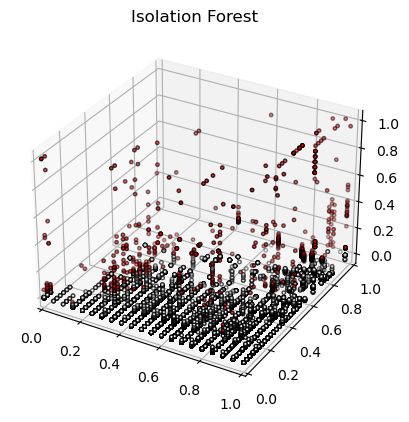

(92805, 7)


In [ ]:

df_data_pre_select = pd.read_csv(path_part0_temp + "sw_select.csv")

df_data_pre_select = df_data_pre_select.rename(columns={'sw_value': 'value'})
df_data_pre_select = df_data_pre_select[df_data_pre_select['value']>0]
print(df_data_pre_select.shape)
df_icicle_w_o_outlier = df_data_pre_select.copy()

print(df_icicle_w_o_outlier.dtypes)



df_icicle_w_o_outlier['year_count'] = df_icicle_w_o_outlier.groupby('posname')['year'].transform('nunique')
df_icicle_w_o_outlier['value_median'] = df_icicle_w_o_outlier.groupby('posname')['value'].transform('median')

sorted_posnames = df_icicle_w_o_outlier.groupby('posname').agg({
    'year_count': 'first',
    'value_median': 'first'
}).sort_values(['year_count', 'value_median'], ascending=[False, False]).index

posname_rank = {name: rank for rank, name in enumerate(sorted_posnames)}
df_icicle_w_o_outlier['posname_rank'] = df_icicle_w_o_outlier['posname'].map(posname_rank)


le_ind = LabelEncoder()
po_le = le_ind.fit_transform(df_icicle_w_o_outlier["posname_rank"])


df_icicle_w_o_outlier["po_copy"] = po_le
df_icicle_w_o_outlier['value_copy'] = (df_icicle_w_o_outlier['value'] - df_icicle_w_o_outlier.groupby('po_copy')['value'].transform('min')) / (df_icicle_w_o_outlier.groupby('po_copy')['value'].transform('max') - df_icicle_w_o_outlier.groupby('po_copy')['value'].transform('min'))
df_icicle_w_o_outlier["year_copy"] = df_icicle_w_o_outlier["year"]
df_icicle_w_o_outlier = get_outlier(df_icicle_w_o_outlier,"year_copy", "po_copy","value_copy", 0.01)


df_icicle_w_o_outlier = df_icicle_w_o_outlier[df_icicle_w_o_outlier["outlier"]==0]

list_3 = ["lon","lat","posname","year", "value", 'n', 'poid']

df_icicle_w_o_outlier = df_icicle_w_o_outlier[list_3]
print(df_icicle_w_o_outlier.shape)
df_icicle_w_o_outlier.to_csv(path_part0_temp + 'sw_outlier.csv',index=False)

In [ ]:

df_outlier = pd.read_csv(path_part0_temp + 'sw_outlier.csv')
print(df_outlier.shape)
list_1 = ["posname","lon","lat","year"]
list_2 = ["posname","lon","lat","year", "n","value"]
list_3 = ["posname","lon","lat","year", "value"]
df_icicle = df_outlier[list_2]

df_icicle_w = mf.get_weight_count(df_icicle,list_1,'mean') 

df_icicle_w_o = df_icicle_w[list_3]
print(df_icicle_w_o.shape)
df_icicle_w_o.to_csv(path_part0_temp + 'sw_weight.csv',index=False)



(92805, 7)
['n', 'value']
posname~lon~lat~year
['posname~lon~lat~year', 'n', 'value']
54214
(54214, 5)


In [ ]:

df_weight = pd.read_csv(path_part0_temp + 'sw_weight.csv')
print(df_weight.shape)
int_grid = 1
def lat_lon_to_grid(lat, lon, grid_size=1):
    return round(lat / grid_size) * grid_size, round(lon / grid_size) * grid_size


df_weight['lat_grid'], df_weight['lon_grid'] = zip(*df_weight.apply(lambda row: lat_lon_to_grid(row['lat'], row['lon'], int_grid), axis=1))


df_grid = df_weight.groupby(['lat_grid', 'lon_grid', 'year', 'posname'])['value'].mean().reset_index()

print(df_grid.shape)

df_grid.to_csv(path_part0_pre + 'sw_grid.csv',index=False)

(54214, 5)
(15128, 5)


In [ ]:
import pandas as pd
df_grid = pd.read_csv(path_part0_pre + "sw_grid.csv")

df_sw_treat = df_grid.copy()


df_type = pd.read_csv("C:/Users/dell/OneDrive/file/nc/type_data.csv")




df_sw_treat = pd.merge(df_sw_treat, df_type, 
                  left_on=['lat_grid', 'lon_grid'], 
                  right_on=['lat', 'lon'], 
                  how='left')

print(df_sw_treat.isnull().sum()[df_sw_treat.isnull().sum() > 0])
columns_to_drop = ['lon', 'lat']
df_sw_treat = df_sw_treat.drop(columns=columns_to_drop)

df_sw_treat.to_csv(path_part0_pre + "sw.csv",index=False)

df_sw_treat = mf.preprocess(df_sw_treat, 'box_cox', ['value'])

df_sw_treat = mf.preprocess(df_sw_treat, 'standardization', ['value'])


df_sw_treat.to_csv(path_part0_pre + "sw_treat.csv",index=False)

Series([], dtype: int64)


### inf

原先是geo数据在全球数据尺度上进行转换然后标准化   
而po和sp是匹配过去再进行的  
这样的处理流程其实并不符合全球预测的需求  
这里会在inf基础上进行转换以及标准化  
原先match和semdata会合并成一个文件  
geo处理单独创建一个文件  

In [ ]:

df_po = pd.read_excel(path_file + "inf.xlsx",sheet_name="po_pfas")
list_po_inf = df_po['poid'][(df_po['log_Koil_w'].notna())&(df_po['density'].notna())].tolist()

df_po = df_po[df_po['poid'].isin(list_po_inf)]
print(df_po.isnull().sum()[df_po.isnull().sum() > 0])
df_po.to_csv(path_part0_pre + "po_select.csv",index=False)

df_lr_select = pd.read_csv(path_part0_temp + 'lr_select.csv')
list_sp_lr = df_lr_select['spid'].unique().tolist()

df_sp = pd.read_excel(path_file + "inf.xlsx",sheet_name="sp_pfas")
df_sp = df_sp[df_sp['spid'].isin(list_sp_lr)]
print(df_sp.isnull().sum()[df_sp.isnull().sum() > 0])
df_sp.to_csv(path_part0_pre + "sp_select.csv",index=False)


po_oname    29
po_fname    23
RfD         45
dtype: int64
latinname    109
dtype: int64


In [ ]:



df_po = pd.read_csv(path_part0_pre + "po_select.csv")
df_sp = pd.read_csv(path_part0_pre + "sp_select.csv")
df_sp = df_sp.rename(columns={"length_last": "sp_length", 'weight_last': 'sp_weight', 'troph_last': 'sp_troph'})


list_po_auto = ["po_carbon","po_f_carbon","po_m_w","logPx","log_Koc", "log_Kow","log_Kaw",
                    "log_Koa","log_Koa_wet","log_KHxd_air","log_Koil_w","log_Koil_air","density","melting_point",
                    "boiling_point","solubility", "log_pKa", "logD5_5", "logD7_4"]

list_sp_auto = ["sp_length","sp_weight","sp_troph"]

df_po_transformation = mf.preprocess(df_po, 'auto', list_po_auto)
df_sp_transformation = mf.preprocess(df_sp, 'auto', list_sp_auto)

df_po_standardization = mf.preprocess(df_po_transformation, 'standardization', list_po_auto)
df_sp_standardization = mf.preprocess(df_sp_transformation, 'standardization', list_sp_auto)

df_po_standardization.to_csv(path_part0_pre + "po_treat.csv",index=False)
df_sp_standardization.to_csv(path_part0_pre + "sp_treat.csv",index=False)

YJ变换列: ['melting_point']
BC变换列: ['logPx', 'po_f_carbon', 'boiling_point', 'po_carbon', 'po_m_w', 'density', 'solubility']
YJ变换列: []
BC变换列: ['sp_length', 'sp_weight', 'sp_troph']


物种由于后续预测需要预先设置好数值  
因此还需要再生成一个表格取四分位数或者聚类    

In [ ]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


file_path = "E:/wyy/code_project/running_outcome/final_data/SPDB/part0_treat/pretreatment/sp_select.csv"
data = pd.read_csv(file_path)


target_cols = ['length_last', 'weight_last', 'troph_last']
identifier_cols = ['spid', 'canonicalName']  # 物种标识列
all_needed_cols = identifier_cols + target_cols


data = data[all_needed_cols].dropna()


def get_cluster_representatives(df, n_clusters=5):

    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(df[target_cols])


    kmeans = KMeans(n_clusters=n_clusters, 
                   random_state=42, 
                   n_init=10)  # 显式设置n_init以避免警告


    import os
    os.environ['OMP_NUM_THREADS'] = '2'

    clusters = kmeans.fit_predict(scaled_data)


    representatives = []
    for cluster_id in range(n_clusters):

        cluster_data = scaled_data[clusters == cluster_id]
        cluster_indices = df.index[clusters == cluster_id]


        center = kmeans.cluster_centers_[cluster_id]
        distances = np.linalg.norm(cluster_data - center, axis=1)


        closest_idx = cluster_indices[np.argmin(distances)]
        representatives.append(closest_idx)


    cluster_df = df.loc[representatives].copy()
    cluster_df.reset_index(inplace=True)
    cluster_df.rename(columns={'index': 'original_index'}, inplace=True)
    cluster_df['index'] = range(len(cluster_df))
    cluster_df['cluster'] = clusters[np.argsort(clusters)][:n_clusters]  # 添加簇标签


    cols = ['index', 'original_index', 'cluster'] + identifier_cols + target_cols
    return cluster_df[cols]



cluster_representatives = get_cluster_representatives(data)




print("\n聚类法选出的代表性物种:")
print(cluster_representatives)
cluster_representatives.to_csv(path_part0_pre + "sp_cluster.csv",index=False)




list_sp_c = cluster_representatives['canonicalName'].tolist()
df_sp_treat = pd.read_csv(path_part0_pre + "sp_treat.csv")
df_sp_treat = df_sp_treat[df_sp_treat['canonicalName'].isin(list_sp_c)]
df_sp_treat['index'] = range(len(df_sp_treat))
df_sp_treat.to_csv(path_part0_pre + "sp_cluster_treat.csv",index=False)


e:\progress\anaconda2\lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(



聚类法选出的代表性物种:
   index  original_index  cluster  spid          canonicalName  length_last  \
0      0             114        0  2396           Gadus morhua        100.0   
1      1             204        0  2895  Catostomus catostomus         22.5   
2      2             131        0  2436            Esox lucius         40.0   
3      3             195        0  2870     Argyrosomus regius        150.0   
4      4             230        0  2936   Pterocaesio digramma         21.3   

    weight_last  troph_last  
0   9771.172850        4.09  
1    148.949030        2.54  
2    384.283995        4.07  
3  39877.093039        4.29  
4    180.976187        3.39  
